# 2. Recolección y preprocesamiento de datos

## 2.1 Recolección de datos

Los datos de PEMS-04 provienen de la red de sensores de tráfico **Caltrans
PeMS** (Performance Measurement System) del distrito 4 (área de la Bahía de
San Francisco), agregados en intervalos de 5 minutos. El conjunto fue
curado y publicado por el grupo de LSTTN (Luo et al., 2024) junto con los
otros tres datasets de la Tabla 1 del Entregable 1, disponible en el Google
Drive enlazado en su repositorio (https://github.com/GeoX-Lab/LSTTN), en el
mismo formato estandarizado que usan trabajos previos como ASTGCN y STSGCN.

Se descargaron dos archivos:
- `PEMS04.npz`: tensor crudo de tráfico, forma `(T, N, C)` = `(16992, 307, 3)`.
- `distance.csv`: lista de aristas `from, to, distance` que describe la
  conectividad vial física entre sensores (distancia en metros/km).

**Limitaciones encontradas:** el dataset no incluye coordenadas geográficas
de los sensores (solo IDs y distancias relativas), por lo que la
visualización del grafo se hace con un layout basado en la topología
(spring layout) en vez de un mapa real. Tampoco se distribuye una matriz de
adyacencia ya construida: debe derivarse de `distance.csv` (sección 2.4).


In [ ]:
# Dependencias
!pip install numpy pandas networkx matplotlib torch torch-geometric

In [ ]:
# Paths (ajustar a la ubicación local de los archivos)
DATA_DIR = "/content/drive/MyDrive/raw_data/PEMS04" # Modificar aqui
NPZ_PATH = f"{DATA_DIR}/PEMS04.npz"
DIST_PATH = f"{DATA_DIR}/PEMS04.csv"

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

np.random.seed(42)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga de datos crudos
raw = np.load(NPZ_PATH)["data"]                 # shape (T, N, C)
distance_df = pd.read_csv(DIST_PATH)             # columns: from, to, distance

T, N, C = raw.shape
FEATURE_NAMES = ["flujo", "ocupacion", "velocidad"]
print(f"Tensor crudo: T={T} pasos, N={N} sensores, C={C} caracteristicas")
distance_df.head()


Tensor crudo: T=16992 pasos, N=307 sensores, C=3 caracteristicas


,from,to,cost
0,73,5,352.6
1,5,154,347.2
2,154,263,392.9
3,263,56,440.8
4,56,96,374.6


## 2.2 Descripción del dataset

A continuación se describe el dataset en su estado crudo: dimensiones,
tipos de dato, rango de valores por característica y proporción de
valores faltantes. Esto justifica las decisiones de preprocesamiento de la
sección 2.3.


In [ ]:
# Estadisticas descriptivas por canal
for c in range(C):
    ch = raw[:, :, c]
    print(f"{FEATURE_NAMES[c]:>10} | min={ch.min():8.2f}  max={ch.max():8.2f}  "
          f"media={ch.mean():8.2f}  std={ch.std():8.2f}")

# Valores faltantes: en PEMS04 los sensores caidos quedan registrados como 0
# en el canal de flujo. Se cuantifica esa proporcion por canal.
for c in range(C):
    zero_ratio = (raw[:, :, c] == 0).mean()
    print(f"Proporcion de ceros en {FEATURE_NAMES[c]}: {zero_ratio:.4%}")


     flujo | min=    0.00  max=  919.00  media=  211.70  std=  158.07
 ocupacion | min=    0.00  max=    0.77  media=    0.05  std=    0.05
 velocidad | min=    3.00  max=   85.20  media=   63.47  std=    8.36
Proporcion de ceros en flujo: 1.5898%
Proporcion de ceros en ocupacion: 1.5919%
Proporcion de ceros en velocidad: 0.0000%


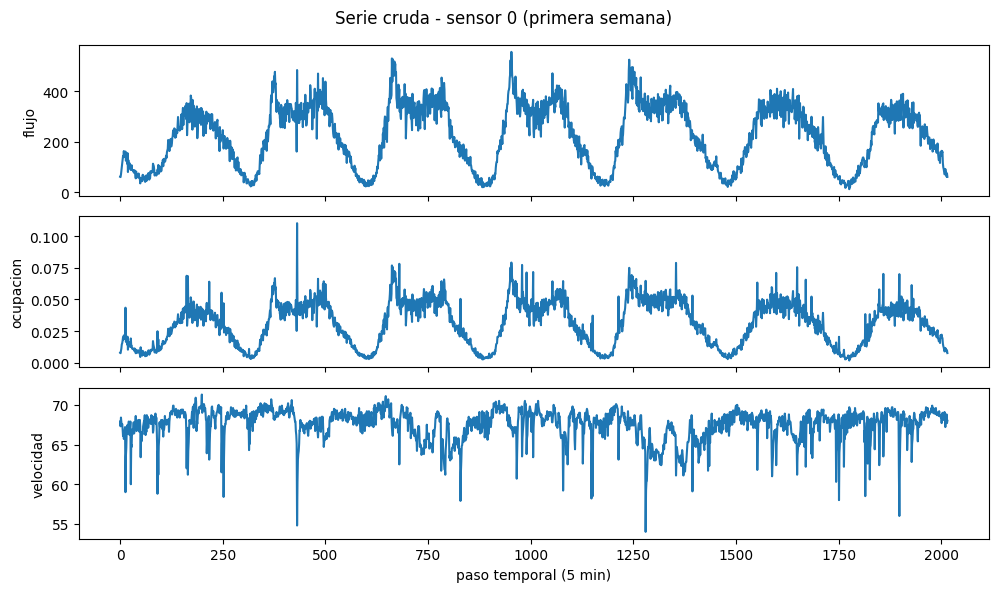

In [ ]:
# Visualizacion de una serie cruda (un sensor, una semana) para inspeccion
sensor_id = 0
window = slice(0, 7 * 24 * 12)  # 7 dias a 5 min/paso

fig, axes = plt.subplots(C, 1, figsize=(10, 6), sharex=True)
for c in range(C):
    axes[c].plot(raw[window, sensor_id, c])
    axes[c].set_ylabel(FEATURE_NAMES[c])
axes[-1].set_xlabel("paso temporal (5 min)")
fig.suptitle(f"Serie cruda - sensor {sensor_id} (primera semana)")
plt.tight_layout()
plt.show()


## 2.3 Preprocesamiento de datos

Pasos aplicados, en orden, antes de construir el grafo y las ventanas de
entrenamiento:

1. **Manejo de valores faltantes**: los ceros del canal de flujo se tratan
   como lecturas faltantes y se interpolan linealmente en el eje temporal,
   por sensor y por canal.
2. **Particionamiento temporal** train/val/test (60/20/20), secuencial
   (sin mezclar el orden temporal, para evitar fuga de información futura).
3. **Normalización** z-score por canal, con media y desviación calculadas
   **solo sobre el split de entrenamiento** y reutilizadas en val/test.
4. **Ventaneo (sliding window)** para generar las secuencias de entrada/
   salida que usará el modelo en el Entregable 3 (12 pasos de historia →
   12 pasos de pronóstico, equivalente a 1 hora de contexto y 1 hora de
   horizonte).


In [ ]:
def interpolate_missing(arr, missing_channel=0):
    """Linear interpolation along the time axis for zero-valued (missing) readings."""
    arr = arr.copy()
    for n in range(arr.shape[1]):
        series = arr[:, n, missing_channel]
        miss = series == 0
        if miss.any() and not miss.all():
            idx = np.arange(len(series))
            series[miss] = np.interp(idx[miss], idx[~miss], series[~miss])
            arr[:, n, missing_channel] = series
    return arr

clean = interpolate_missing(raw, missing_channel=0)
print("Ceros restantes en flujo tras interpolar:", (clean[:, :, 0] == 0).mean())


Ceros restantes en flujo tras interpolar: 0.0


In [ ]:
# Particion temporal secuencial 60/20/20
n_train = int(T * 0.6)
n_val = int(T * 0.2)

train_raw = clean[:n_train]
val_raw = clean[n_train:n_train + n_val]
test_raw = clean[n_train + n_val:]
print("train/val/test shapes:", train_raw.shape, val_raw.shape, test_raw.shape)


train/val/test shapes: (10195, 307, 3) (3398, 307, 3) (3399, 307, 3)


In [ ]:
# Normalizacion z-score (estadisticas calculadas solo con train)
mean = train_raw.mean(axis=(0, 1), keepdims=True)
std = train_raw.std(axis=(0, 1), keepdims=True) + 1e-8

train_norm = (train_raw - mean) / std
val_norm = (val_raw - mean) / std
test_norm = (test_raw - mean) / std

print("media post-norm (train):", train_norm.mean().round(4))
print("std post-norm (train):", train_norm.std().round(4))


media post-norm (train): 0.0
std post-norm (train): 1.0


In [ ]:
def sliding_window(arr, in_len=12, out_len=12):
    """Build (X, Y) supervised pairs via a sliding window over the time axis."""
    n_steps = arr.shape[0] - in_len - out_len + 1
    X = np.stack([arr[t:t + in_len] for t in range(n_steps)])
    Y = np.stack([arr[t + in_len:t + in_len + out_len] for t in range(n_steps)])
    return X, Y

X_train, Y_train = sliding_window(train_norm)
X_val, Y_val = sliding_window(val_norm)
X_test, Y_test = sliding_window(test_norm)

print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)


X_train: (10172, 12, 307, 3) | Y_train: (10172, 12, 307, 3)


## 2.4 Construcción del grafo

Siguiendo el modelamiento del Entregable 1 (grafo $G=(V,E,A)$ dirigido y
ponderado):

- **Nodos ($V$)**: un nodo por sensor (`N = 307`). El atributo de cada nodo
  es el vector de características promedio en el split de entrenamiento
  (flujo, ocupación, velocidad), usado solo para inspección/visualización
  estática; el tensor temporal completo (`X_train`, `X_val`, `X_test`) es el
  que alimentará al modelo en el Entregable 3.
- **Aristas ($E$)**: se toman directamente de `distance.csv`. Cada fila
  `(from, to, distance)` define una arista dirigida que respeta el sentido
  real de circulación vial.
- **Matriz de adyacencia ($A$)**: se pondera cada arista con un kernel
  gaussiano sobre la distancia, $w_{ij} = \exp(-d_{ij}^2/\sigma^2)$, donde
  $\sigma$ es la desviación estándar de las distancias observadas. Esto da
  más peso a sensores físicamente cercanos.


In [ ]:
def build_adjacency_matrix(distance_df, num_nodes):
    """Bidirectional binary connectivity (matches LSTTN's get_adjacency_matrix_2direction);
    a separate gaussian-weighted matrix is kept for edge_attr."""
    A_bin = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    A_weighted = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    dists = distance_df["cost"].values
    sigma2 = dists.std() ** 2
    for f, t, d in zip(distance_df["from"], distance_df["to"], distance_df["cost"]):
        f, t = int(f), int(t)
        w = np.exp(-(d ** 2) / sigma2)
        A_bin[f, t] = 1
        A_bin[t, f] = 1
        A_weighted[f, t] = w
        A_weighted[t, f] = w
    return A_bin, A_weighted

A_bin, A = build_adjacency_matrix(distance_df, N)
n_edges_no_loops = int((A_bin > 0).sum())
print("Aristas sin self-loops:", n_edges_no_loops)
print("Aristas + self-loops (convencion GCN, A+I):", n_edges_no_loops + N)
print("Densidad:", n_edges_no_loops / (N * N))

Aristas sin self-loops: 680
Aristas + self-loops (convencion GCN, A+I): 987
Densidad: 0.007214930662394296


In [ ]:
# Objeto Data de PyTorch Geometric
rows, cols = np.nonzero(A_bin)
edge_index = torch.tensor(np.array([rows, cols]), dtype=torch.long)
edge_weight = torch.tensor(A[rows, cols], dtype=torch.float)

node_features = torch.tensor(train_raw.mean(axis=0), dtype=torch.float)  # (N, C)
graph_data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_weight)
print(graph_data)


Data(x=[307, 3], edge_index=[2, 680], edge_attr=[680])


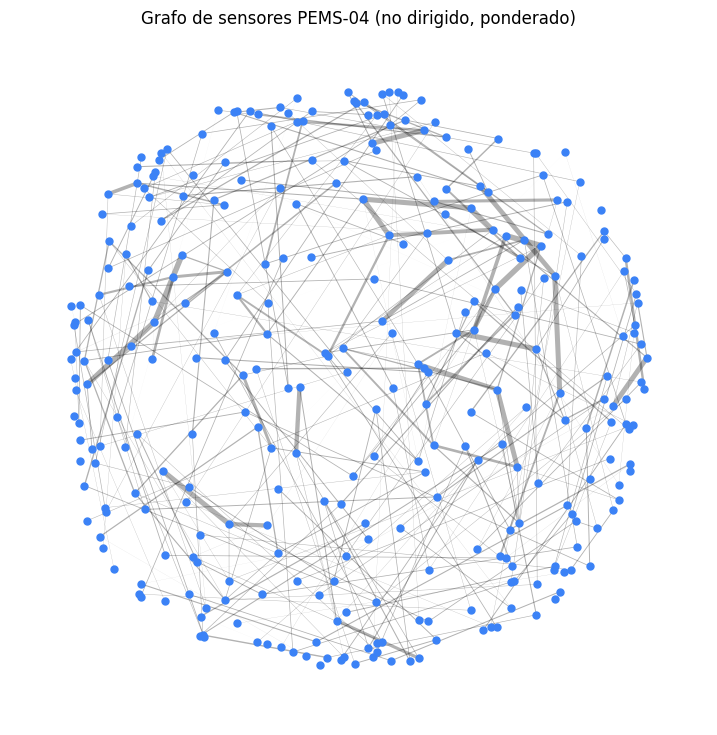

In [ ]:
# Visualizacion del grafo (layout topologico: no hay coordenadas geograficas)
G = nx.Graph()
G.add_nodes_from(range(N))
rows, cols = np.nonzero(A_bin)
G.add_edges_from((int(r), int(c), {"weight": A[r, c]}) for r, c in zip(rows, cols) if r <= c)

pos = nx.spring_layout(G, seed=42, k=0.3)
weights = [G[u][v]["weight"] * 4 for u, v in G.edges()]

plt.figure(figsize=(9, 9))
nx.draw_networkx_nodes(G, pos, node_size=25, node_color="#3b82f6")
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.3)
plt.title("Grafo de sensores PEMS-04 (no dirigido, ponderado)")
plt.axis("off")
plt.show()


## 2.5 Análisis estructural del grafo

Métricas básicas a nivel de nodo, arista y grafo completo, sobre el grafo
dirigido construido en 2.4.


In [ ]:
deg = dict(G.degree())

print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")
print(f"Densidad: {nx.density(G):.5f}")
print(f"Grado promedio: {np.mean(list(deg.values())):.2f}")
print(f"Componentes conexas: {nx.number_connected_components(G)}")
print(f"Coeficiente de clustering promedio: {nx.average_clustering(G):.4f}")

Nodos: 307 | Aristas: 340
Densidad: 0.00724
Grado promedio: 2.21
Componentes conexas: 12
Coeficiente de clustering promedio: 0.0583


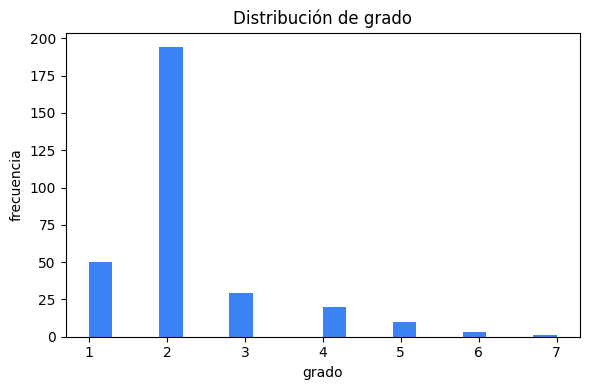

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(list(deg.values()), bins=20, color="#3b82f6")
plt.title("Distribución de grado")
plt.xlabel("grado")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

# 3. Análisis basado en GML

Este enfoque utiliza modelos de machine learning con grafos (Graph Neural Networks) para realizar predicciones de flujo de tráfico futuro a partir de datos estructurados espaciotemporalmente.

### 3.1. Seleccionar el modelo adecuado para la tarea y el tipo de grafo

* **Nivel de análisis y tarea de aprendizaje:** El análisis se realiza a **nivel de nodo**. La tarea es la predicción de series temporales continuas (regresión), específicamente pronosticar el flujo de tráfico futuro de cada sensor basándonos en su histórico y en la topología vial.
* **Modelo seleccionado:** Implementaremos una arquitectura basada en **Spatio-Temporal Graph Convolutional Network (STGCN)**. Usaremos capas de convolución de grafos (`GCNConv`) para extraer características espaciales de la red vial, combinadas con capas lineales para manejar la dimensión temporal y proyectar el pronóstico hacia el futuro.
* **Estrategia de validación:** Se mantendrá la partición cronológica (train/val/test) realizada en la fase de preprocesamiento para evitar el *data leakage* (fuga de información del futuro hacia el pasado).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Asegurarnos de usar GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Movemos los elementos del grafo (creados en la sección 2.4) al dispositivo
edge_index = edge_index.to(device)
edge_weight = edge_weight.to(device)

# Adaptación de las secuencias temporales para el Grafo
# Asumimos que X_train de la sección 2 tiene la forma: (Muestras, Tiempo, Nodos, Canales)
# Extraemos solo la variable "flujo" (canal 0) y ajustamos las dimensiones para el modelo.
# El modelo GNN que diseñaremos espera la forma: (Muestras, Nodos, Atributos_temporales)

window_size = 12 # 12 pasos históricos = 1 hora (Asumido del entregable 2)
horizon = 3      # Queremos predecir los próximos 3 pasos = 15 minutos

# Transponemos y extraemos el flujo: [Muestras, Nodos, Tiempo]
X_train_t = torch.tensor(X_train[:, :, :, 0].transpose(0, 2, 1), dtype=torch.float)
X_val_t   = torch.tensor(X_val[:, :, :, 0].transpose(0, 2, 1), dtype=torch.float)
X_test_t  = torch.tensor(X_test[:, :, :, 0].transpose(0, 2, 1), dtype=torch.float)

# Para "Y", tomamos solo la longitud del horizonte de predicción
Y_train_t = torch.tensor(Y_train[:, :horizon, :, 0].transpose(0, 2, 1), dtype=torch.float)
Y_val_t   = torch.tensor(Y_val[:, :horizon, :, 0].transpose(0, 2, 1), dtype=torch.float)
Y_test_t  = torch.tensor(Y_test[:, :horizon, :, 0].transpose(0, 2, 1), dtype=torch.float)

print(f"Nuevas dimensiones Train: X={X_train_t.shape}, Y={Y_train_t.shape}")
print(f"Nuevas dimensiones Val:   X={X_val_t.shape}, Y={Y_val_t.shape}")
print(f"Nuevas dimensiones Test:  X={X_test_t.shape}, Y={Y_test_t.shape}")

Usando dispositivo: cuda
Nuevas dimensiones Train: X=torch.Size([10172, 307, 12]), Y=torch.Size([10172, 307, 3])
Nuevas dimensiones Val:   X=torch.Size([3375, 307, 12]), Y=torch.Size([3375, 307, 3])
Nuevas dimensiones Test:  X=torch.Size([3376, 307, 12]), Y=torch.Size([3376, 307, 3])


### 3.2. Entrenamiento y optimización de hiperparámetros

* **Arquitectura del Modelo:** Dos capas `GCNConv` seguidas de una capa lineal. La entrada de cada nodo es su serie histórica de tiempo, permitiendo que la red asimile simultáneamente la dinámica temporal y la estructura espacial.
* **Hiperparámetros:** * *Tasa de aprendizaje:* 0.001 con optimizador Adam.
  * *Canales ocultos:* 32 dimensiones.
  * *Batch Size:* 64
  * *Épocas:* 50
* **Monitoreo:** Mean Squared Error (MSE) calculado por lotes para las fases de entrenamiento y validación.

Iniciando entrenamiento del modelo STGCN...
Epoch 01/50 | Train Loss (MSE): 0.1996 | Val Loss (MSE): 0.1263
Epoch 05/50 | Train Loss (MSE): 0.1079 | Val Loss (MSE): 0.1156
Epoch 10/50 | Train Loss (MSE): 0.1056 | Val Loss (MSE): 0.1133
Epoch 15/50 | Train Loss (MSE): 0.1027 | Val Loss (MSE): 0.1101
Epoch 20/50 | Train Loss (MSE): 0.0991 | Val Loss (MSE): 0.1062
Epoch 25/50 | Train Loss (MSE): 0.0955 | Val Loss (MSE): 0.1029
Epoch 30/50 | Train Loss (MSE): 0.0923 | Val Loss (MSE): 0.0996
Epoch 35/50 | Train Loss (MSE): 0.0899 | Val Loss (MSE): 0.0965
Epoch 40/50 | Train Loss (MSE): 0.0882 | Val Loss (MSE): 0.0949
Epoch 45/50 | Train Loss (MSE): 0.0870 | Val Loss (MSE): 0.0935
Epoch 50/50 | Train Loss (MSE): 0.0860 | Val Loss (MSE): 0.0921


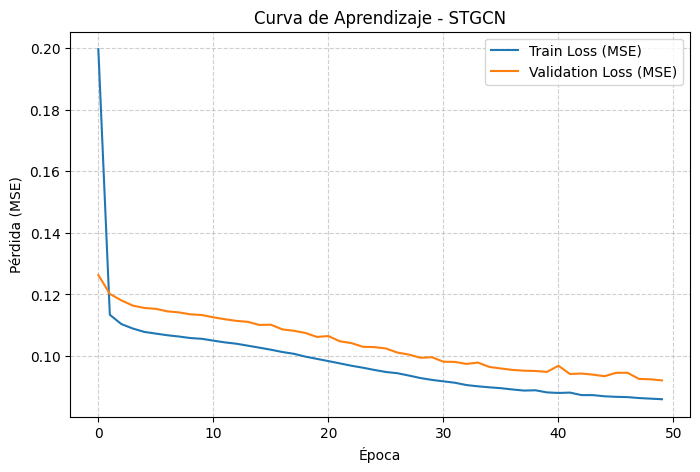

In [ ]:
# Hiperparámetros
hidden_channels = 32
batch_size = 64
learning_rate = 0.001
epochs = 50

# Creación de DataLoaders
train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Definición del Modelo
class SimpleSTGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(SimpleSTGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, batch_x, edge_index, edge_weight):
        # batch_x shape: [Batch_size, Nodos, Features]
        # GCNConv en PyTorch Geometric espera [Nodos, Features], por lo que iteramos el batch
        out_batch = []
        for i in range(batch_x.size(0)):
            x = batch_x[i]
            x = self.conv1(x, edge_index, edge_weight)
            x = F.relu(x)
            x = self.conv2(x, edge_index, edge_weight)
            x = F.relu(x)
            x = self.linear(x)
            out_batch.append(x)
        return torch.stack(out_batch) # Retorna [Batch_size, Nodos, Horizon]

model = SimpleSTGCN(in_channels=window_size, hidden_channels=hidden_channels, out_channels=horizon).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Bucle de Entrenamiento
train_losses, val_losses = [], []

print("Iniciando entrenamiento del modelo STGCN...")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        pred = model(batch_x, edge_index, edge_weight)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * batch_x.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Fase de Validación
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            pred = model(batch_x, edge_index, edge_weight)
            loss = criterion(pred, batch_y)
            epoch_val_loss += loss.item() * batch_x.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss (MSE): {epoch_train_loss:.4f} | Val Loss (MSE): {epoch_val_loss:.4f}")

# Gráfica de la convergencia del entrenamiento
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss (MSE)', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss (MSE)', color='#ff7f0e')
plt.title('Curva de Aprendizaje - STGCN')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3.3. Evaluación

* **Métricas de evaluación:** Evaluaremos el desempeño usando las métricas estándar en predicción de tráfico (las mismas reportadas en el paper de LSTTN y modelos similares):
  1. **MAE (Mean Absolute Error):** Error promedio absoluto en unidades reales de vehículos.
  2. **RMSE (Root Mean Squared Error):** Penaliza los errores de predicción grandes.
  3. **MAPE (Mean Absolute Percentage Error):** Mide el porcentaje de error respecto al valor real.
* **Comparaciones con la línea base:** Utilizaremos un modelo *Historical Average (HA)* local como línea base. Este modelo asume ingenuamente que la predicción futura es simplemente el promedio del tráfico en la ventana histórica observada.

     RESULTADOS DE EVALUACIÓN (TEST SET)      
MÉTRICA         | STGCN (GNN)     | LÍNEA BASE (HA)
--------------------------------------------------
MAE             | 30.33           | 28.15          
RMSE            | 46.76           | 41.65          
MAPE (%)        | 31.78           | 21.27          


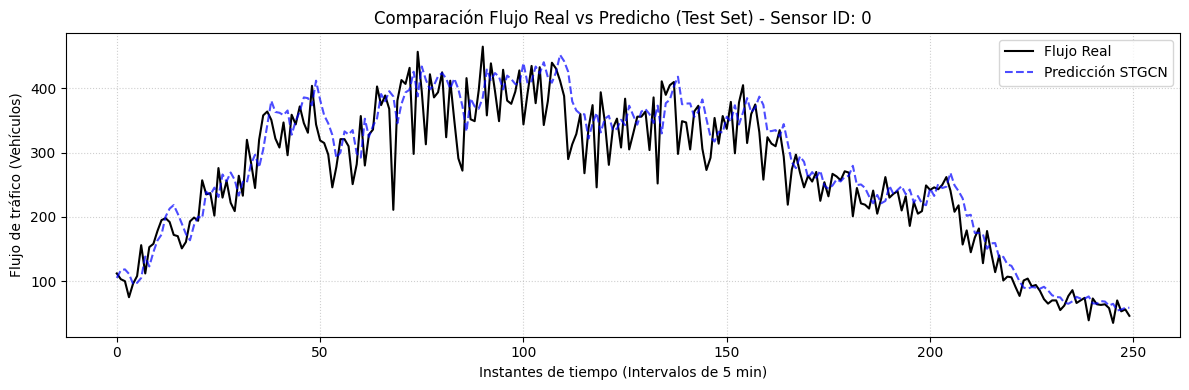

In [ ]:
# Funciones para las métricas de evaluación
def calc_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))

def calc_mape(y_true, y_pred):
    # Epsilon para evitar división por cero en instantes sin tráfico
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

# Recuperamos las variables de normalización de la sección 2
# Nota: Ajusta los índices si tu variable `mean` o `std` tiene otra forma.
# Asumimos que mean y std son arreglos donde el canal 0 es el flujo.
try:
    mean_flujo = mean[0, 0, 0] if mean.ndim == 3 else mean[0]
    std_flujo = std[0, 0, 0] if std.ndim == 3 else std[0]
except:
    # Fallback genérico en caso de que mean/std sean escalares u otra estructura
    mean_flujo = np.mean(mean)
    std_flujo = np.mean(std)

# Preparar Test Loader y predecir
test_dataset = TensorDataset(X_test_t, Y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        pred = model(batch_x, edge_index, edge_weight)
        all_preds.append(pred.cpu().numpy())
        all_trues.append(batch_y.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

# Desnormalizar predicciones para calcular métricas en valores reales (vehículos)
all_preds_real = (all_preds * std_flujo) + mean_flujo
all_trues_real = (all_trues * std_flujo) + mean_flujo

# El flujo de tráfico no puede ser negativo
all_preds_real = np.maximum(0, all_preds_real)

# Cálculo del Baseline (Historical Average de la ventana)
X_test_real = (X_test_t.numpy() * std_flujo) + mean_flujo
# HA: Promedio a lo largo de la dimensión temporal histórica (axis=2)
baseline_pred = np.mean(X_test_real, axis=2, keepdims=True)
# Repetimos ese promedio para los 'horizon' pasos a predecir
baseline_pred = np.repeat(baseline_pred, horizon, axis=2)

# Resultados y Comparación
print("="*50)
print("     RESULTADOS DE EVALUACIÓN (TEST SET)      ")
print("="*50)
print(f"{'MÉTRICA':<15} | {'STGCN (GNN)':<15} | {'LÍNEA BASE (HA)':<15}")
print("-" * 50)

mae_stgcn  = calc_mae(all_trues_real, all_preds_real)
rmse_stgcn = calc_rmse(all_trues_real, all_preds_real)
mape_stgcn = calc_mape(all_trues_real, all_preds_real)

mae_base  = calc_mae(all_trues_real, baseline_pred)
rmse_base = calc_rmse(all_trues_real, baseline_pred)
mape_base = calc_mape(all_trues_real, baseline_pred)

print(f"MAE             | {mae_stgcn:<15.2f} | {mae_base:<15.2f}")
print(f"RMSE            | {rmse_stgcn:<15.2f} | {rmse_base:<15.2f}")
print(f"MAPE (%)        | {mape_stgcn:<15.2f} | {mape_base:<15.2f}")
print("="*50)

# Visualización: Predicción vs Realidad
nodo_id = 0             # Sensor elegido para visualizar
horizonte_obj = 0       # Visualizamos la predicción a t+1 (el primer paso del horizonte)
muestras_vis = 250      # Cantidad de instantes de tiempo del test a graficar

plt.figure(figsize=(12, 4))
plt.plot(all_trues_real[:muestras_vis, nodo_id, horizonte_obj], label='Flujo Real', color='black', linewidth=1.5)
plt.plot(all_preds_real[:muestras_vis, nodo_id, horizonte_obj], label='Predicción STGCN', color='blue', alpha=0.7, linestyle='--')
plt.title(f'Comparación Flujo Real vs Predicho (Test Set) - Sensor ID: {nodo_id}')
plt.xlabel('Instantes de tiempo (Intervalos de 5 min)')
plt.ylabel('Flujo de tráfico (Vehículos)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()